![t](images/PS1_3.jpg)

In [1]:
import numpy as np
from src import util

from src.linear_model import LinearModel

In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
class PoissonRegression(LinearModel):
    def h(self,x,theta):
            return np.exp(x@theta)
    def fit(self,x,y,alpha=2e-7):
        m,n=x.shape
        
        self.theta=np.zeros(n)
        
        theta_pr=np.copy(self.theta)+1 
        while np.linalg.norm(self.theta-theta_pr,ord=1)>=self.eps:
            theta_pr=np.copy(self.theta)
            
            self.theta+=alpha/m*x.T@(y-self.h(x,self.theta))
            
    def predict(self,x):
        return self.h(x,self.theta)
    

In [4]:
x_train4, y_train4= util.load_dataset("data/ds4_train.csv", add_intercept=True)

x_val4, y_val4 = util.load_dataset("data/ds4_valid.csv", add_intercept=True)

In [5]:
pr=PoissonRegression()
pr.fit(x_train4,y_train4)
pr_predictions=pr.predict(x_val4)
f"average error of pr on 4th data set: {np.mean(np.abs(pr_predictions-y_val4))}"

'average error of pr on 4th data set: 1247.5888002728502'

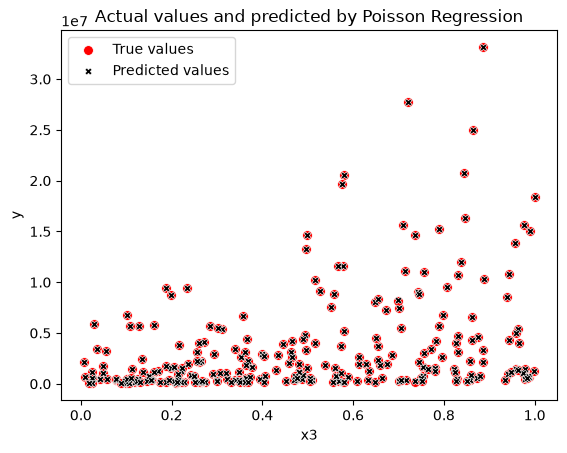

In [7]:
fig,ax=plt.subplots()
sns.scatterplot(x=x_val4[:,3],y=y_val4,color='red',s=50,label="True values")
sns.scatterplot(x=x_val4[:,3],y=pr_predictions,color='black',marker='X',s=25,label="Predicted values")
ax.set_title("Actual values and predicted by Poisson Regression")
ax.set_xlabel('x3')
ax.set_ylabel('y')
plt.show()